# California Housing Dataset
Este conjunto de datos de viviendas de California proporciona una variedad de características socioeconómicas y geográficas para los distritos censales en California. Este conjunto de datos nos servirá para ver el uso de los Árboles y Bosques Aleatorios para regresión por la complejidad en los datos. En primer lugar haremos un análisis exploratorio de los datos, y terminaremos creando un modelo de regresión lineal simple para saber que tan bueno es este modelo de regresión sencillo y terminaremos creando los últimos algoritmos del video.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib as path
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [ ]:
path = path.Path('/content/sample_data/housing.csv')

In [ ]:
data = pd.read_csv(path)

realizamos analisis exploratorio

In [ ]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.00,880.00,129.00,322.00,126.00,8.33,452600.00,NEAR BAY
1,-122.22,37.86,21.00,7099.00,1106.00,2401.00,1138.00,8.30,358500.00,NEAR BAY
2,-122.24,37.85,52.00,1467.00,190.00,496.00,177.00,7.26,352100.00,NEAR BAY
3,-122.25,37.85,52.00,1274.00,235.00,558.00,219.00,5.64,341300.00,NEAR BAY
4,-122.25,37.85,52.00,1627.00,280.00,565.00,259.00,3.85,342200.00,NEAR BAY


In [ ]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

la unica columna que no es un float es ocean_proximity

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


In [ ]:
pd.reset_option('display.float_format')

vemos que datos son nulos

In [ ]:
data.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


vemos el conteo de la columna 'ocena_proximity

In [ ]:
data['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


veremso las columnas de forma grafica, realizando un histograma

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

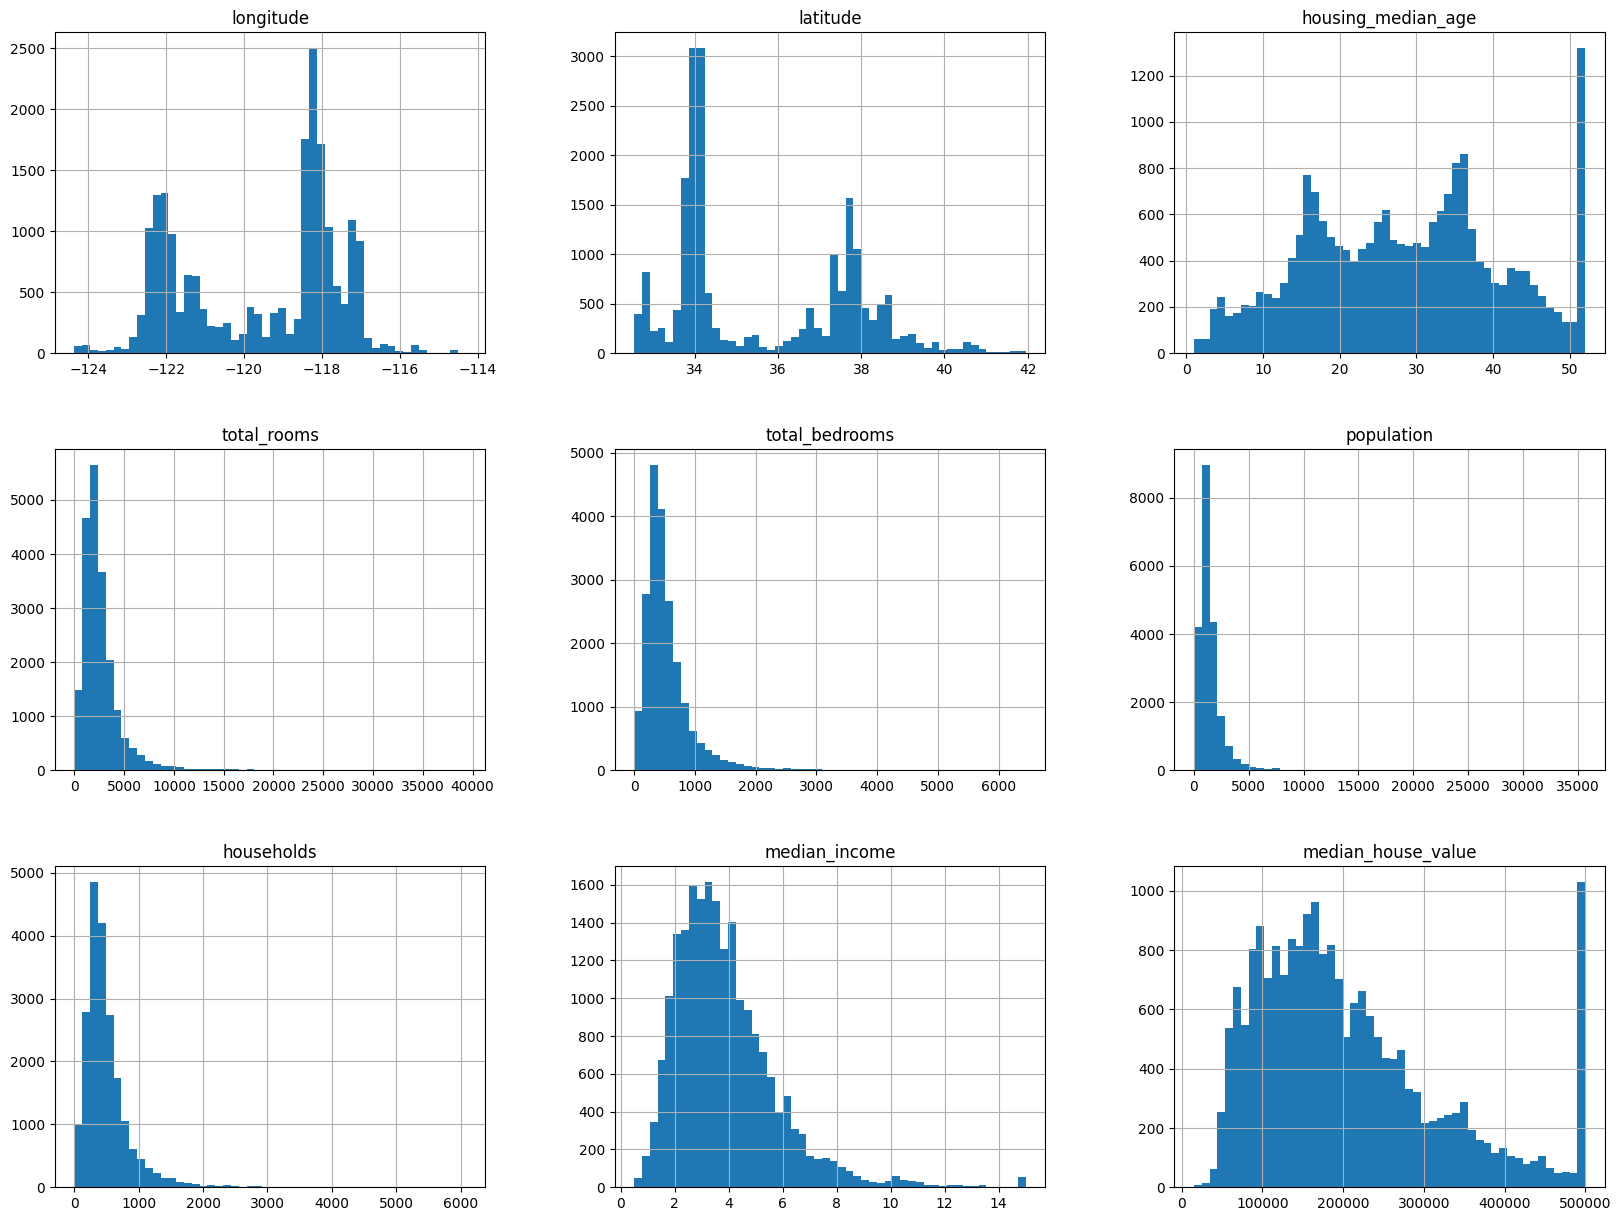

In [ ]:
# el histograma solo se realiza para las columnas numericas
data.hist(bins=50,figsize=(20,15))

al no haber una distribucion estandar, esto afectara a nuestro modelo, para lo cual luego normalizaremos los datos

las longitudes y latitudes no se aprecian bien en un grafico de histograma

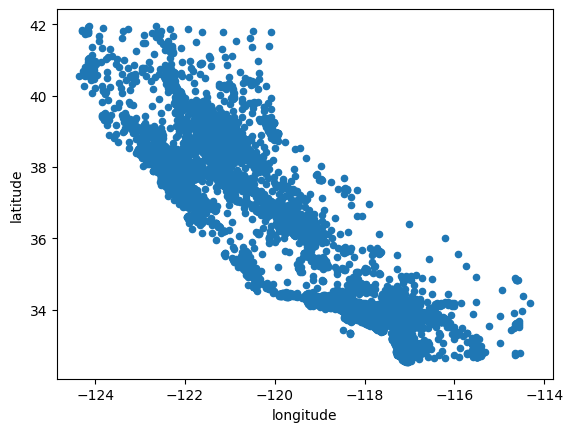

In [ ]:
data.plot(kind='scatter', x='longitude', y='latitude')
plt.show()

podemos apreciar como se ve la forma de california, modificaremos la opacidad de los puntos

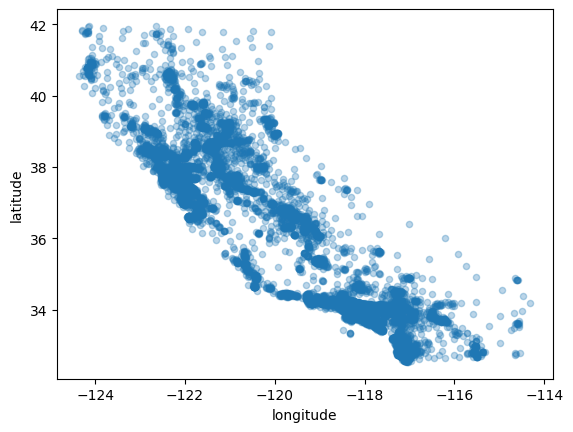

In [ ]:
data.plot(kind='scatter', x='longitude', y='latitude', alpha=0.3)
plt.show()

ahora agregaremos el parametro s que modificara el tamaño de los puntos, puntualmente nosotros definiremos el tamaño teniendo en cuenta la cantidad de habitante spor bloque.

luego tambien agregaremos el parametro label

tambien modificaremos el tamaño del grafico

utilizaremos el parametro c que modifica el color de los puntos, este lo utilizaremos para pintar los puntos de distinto color dependiendo el valor medio de las casas, pasandole los colores con el parametro cmap

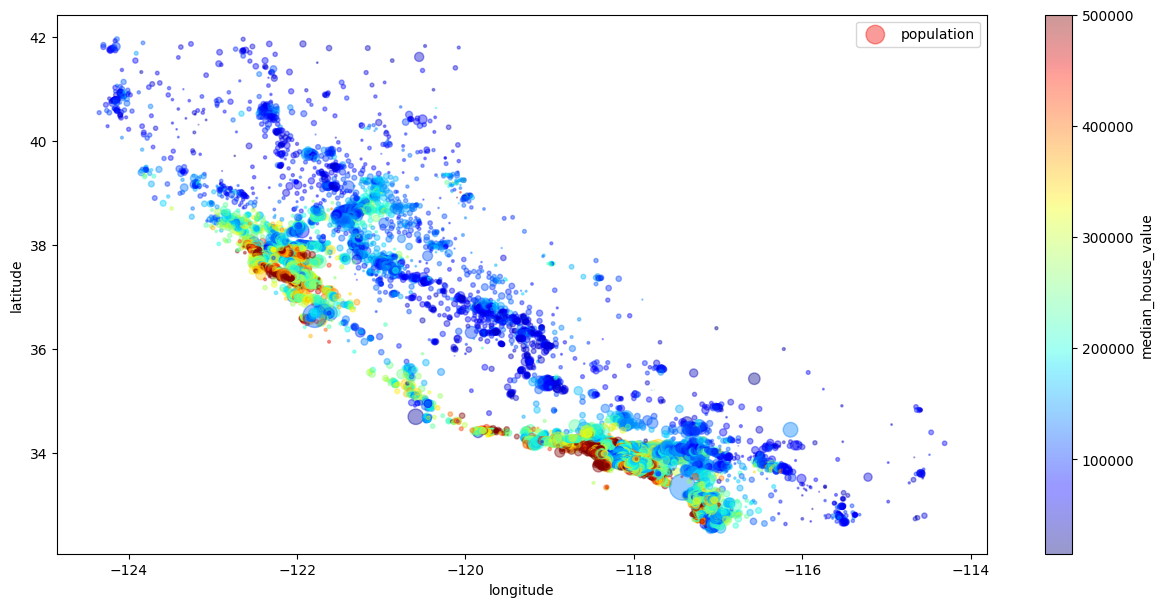

In [ ]:
data.plot(kind='scatter', x='longitude', y='latitude', alpha=0.4, s=data['population']/100, label='population', figsize=(15,7)
        ,c= 'median_house_value', cmap= plt.get_cmap('jet'), colorbar= True)
# permite que se vea la leyenda
plt.legend()
plt.show()

### Queremos saber las correlaciones entre variabes

/tmp/ipython-input-2300985129.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Axes: >

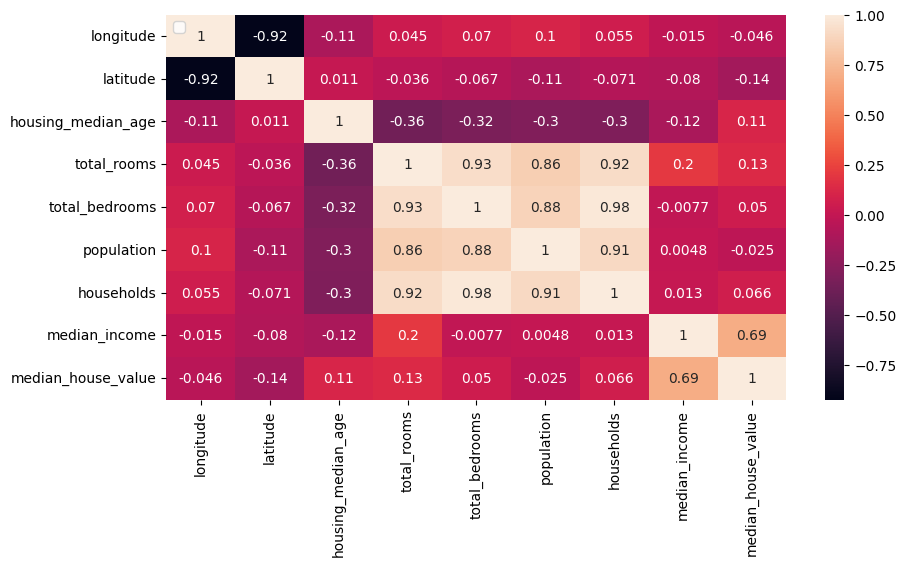

In [ ]:
plt.figure(figsize=(10,5))
plt.legend()
sns.heatmap(data.drop(columns='ocean_proximity').corr(), annot=True)

alamcenamos las correlaciones en una matriz

In [ ]:
corr_matrix = data.drop('ocean_proximity',axis=1).corr()
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


ordeno los valores

In [ ]:
corr_matrix['median_house_value'].drop('median_house_value').sort_values(ascending=False)

,median_house_value
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


## Transformacion de variables


### Combinacion de atributos
combinaremos los valores de varias variables

* *rooms_per_household* : Representa el número medio de habitaciones por hogar en una cierta área. Proporciona una medida de la densidad de habitaciones en una vivienda promedio en esa área.

* *bedrooms_per_room* : Indica la proporción de dormitorios con respecto al número total de habitaciones en una cierta área.

* *population_per_household* : Representa la densidad de población promedio por hogar en una cierta área.

In [ ]:
# agregamos las columnas de nuestras nuevas variables

data['rooms_per_household'] = data['total_rooms'] / data['households']

data['bedrooms_per_room'] = data['total_bedrooms'] / data['total_rooms']

data['population_per_household'] = data['population'] / data['households']

In [ ]:
display(data.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467


In [ ]:
corr_matrix = data.drop('ocean_proximity',axis=1).corr()

display(corr_matrix['median_house_value'].drop('median_house_value').sort_values(ascending=False))

,median_house_value
median_income,0.688075
rooms_per_household,0.151948
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population_per_household,-0.023737
population,-0.024650
longitude,-0.045967
latitude,-0.144160


### Trabajando con datos nulos y atributos categoricos

Rellenaremos los valores nulos, para evitar errores en el fit.

Ademas que transformaremos los datos de la columna de 'ocean_proximity' para que se convierta en valores numericos

primero rellenaremos los datos nulos de la columna 'total_bedrooms'

#### Uno de los metodos, rellenar los valores nulos con la mediana


In [ ]:
# remplazamos los valores nulos por la mediana
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].median())

no haremos nada con bedrooms_per_person ya que es una medida que nosotros sacamos

#### Manipulacion de los datos categoricos

los que haremos es modificar los datos que nos sun numericos y los transformaremos a numeros para poder utilizarlos en el modelo.


Utilizarmos ordinalencoder


```
from sklearn.preprocessing import OrdinalEncoder
```



In [ ]:
data_ocean = data[['ocean_proximity']]
Ordinal_encoder = OrdinalEncoder()

In [ ]:
data_ocean_encoded = Ordinal_encoder.fit_transform(data_ocean)

veremos como se califico los datos de data_ocean, utilizando el metodo random de numpy

In [ ]:
np.random.choice(data_ocean_encoded.ravel(), size=10)

array([0., 3., 0., 0., 3., 3., 0., 4., 0., 4.])

este metodo no es muy eficiente ya que no el algoritmo no distingue que son categoricos y puede crear correlaciones erroneas

#### Utilizarmos otra funcion

con la que podremos cambiar su disposicion categoriaca a numerica de forma eficaz

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
cat_encoder = OneHotEncoder()
data_car_1hot = cat_encoder.fit_transform(data_ocean)

In [ ]:
data_car_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

podemos ver que le da una categoria propia siendo que el 1 se situa en la categoria donde debe estar

In [ ]:
encoded_df = pd.DataFrame(data_car_1hot.toarray(), columns= cat_encoder.get_feature_names_out())

encoded_df.head(5)



,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0


## Entrenaremos el modelo

crearemos variables dependiente e independientes

variable dependiente

In [ ]:
y = data['median_house_value'].values.reshape(-1,1)

y[:5]

array([[452600.],
       [358500.],
       [352100.],
       [341300.],
       [342200.]])

Variables independientes

In [ ]:
X = data[[
    'median_income',
    'rooms_per_household',
    'total_rooms',
    'housing_median_age',
    'households'
]]

In [ ]:
X[:5]

,median_income,rooms_per_household,total_rooms,housing_median_age,households
0,8.3252,6.984127,880.0,41.0,126.0
1,8.3014,6.238137,7099.0,21.0,1138.0
2,7.2574,8.288136,1467.0,52.0,177.0
3,5.6431,5.817352,1274.0,52.0,219.0
4,3.8462,6.281853,1627.0,52.0,259.0


utilizando el metodo concat agregamos los valores de ocean_proximity

In [ ]:
data1 = pd.concat([X, encoded_df], axis=1)
data1.columns

Index(['median_income', 'rooms_per_household', 'total_rooms',
       'housing_median_age', 'households', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [ ]:
X = data1.values

X[:5]

array([[8.32520000e+00, 6.98412698e+00, 8.80000000e+02, 4.10000000e+01,
        1.26000000e+02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00],
       [8.30140000e+00, 6.23813708e+00, 7.09900000e+03, 2.10000000e+01,
        1.13800000e+03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00],
       [7.25740000e+00, 8.28813559e+00, 1.46700000e+03, 5.20000000e+01,
        1.77000000e+02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00],
       [5.64310000e+00, 5.81735160e+00, 1.27400000e+03, 5.20000000e+01,
        2.19000000e+02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00],
       [3.84620000e+00, 6.28185328e+00, 1.62700000e+03, 5.20000000e+01,
        2.59000000e+02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00]])

## Primero generaremos un modelo de Regrasion Lineal Multiple

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(y_train.shape)

(16512, 10)
(16512, 1)


In [ ]:
lin_reg = LinearRegression()

In [ ]:
lin_reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lin_reg.predict(X_test)

luego haremos el score

In [ ]:
r2 = r2_score(y_test, y_pred)
r2

0.5934326451877903

### Escalando variables
haremos que todas las variables esten un mismo nivel, es decir ponderaremos los pesos para que no afecte al modelo

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc_X = StandardScaler()
# escalamos las variables del conjunto
X = sc_X.fit_transform(X)
X[:2]

array([[ 2.34476576,  0.62855945, -0.8048191 ,  0.98214266, -0.97703285,
        -0.89115574, -0.68188905, -0.01556621,  2.83074203, -0.38446649],
       [ 2.33223796,  0.32704136,  2.0458901 , -0.60701891,  1.66996103,
        -0.89115574, -0.68188905, -0.01556621,  2.83074203, -0.38446649]])

In [ ]:
# entranamiento del modelo

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()

lin_reg.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = lin_reg.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
r2

0.5934326451877903

vemos que no afecto el valor del modelo, ahora agregaremos el las variables creadas por nosotros y ver si afectan o no

In [ ]:
# Creación del modelo columna por columna
columnas = ['median_income', 'rooms_per_household','total_rooms','housing_median_age','households', 'latitude', 'longitude']
col_modelo = []
y = data['median_house_value'].values.reshape(-1,1)

for col in columnas:
  col_modelo.append(col)
  data1 = data[col_modelo]
  data1 = pd.concat([data1, encoded_df], axis=1)
  X = data1.values

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  lin_reg = LinearRegression()
  lin_reg.fit(X_train, y_train)
  y_pred = lin_reg.predict(X_test)
  r2 = r2_score(y_test, y_pred)
  print(col_modelo, r2)

['median_income'] 0.5878057336563691
['median_income', 'rooms_per_household'] 0.5938431829156319
['median_income', 'rooms_per_household', 'total_rooms'] 0.5907755303137505
['median_income', 'rooms_per_household', 'total_rooms', 'housing_median_age'] 0.6161596791994173
['median_income', 'rooms_per_household', 'total_rooms', 'housing_median_age', 'households'] 0.61573107815462
['median_income', 'rooms_per_household', 'total_rooms', 'housing_median_age', 'households', 'latitude'] 0.5916330744919026
['median_income', 'rooms_per_household', 'total_rooms', 'housing_median_age', 'households', 'latitude', 'longitude'] 0.6235736631712552
